# Capstone — Production-Ready Agent System, Evaluation & Deployment
### Web3Geeks Support Ticket Triage & Resolution Agent

Days 1-4 built up the pieces one at a time: a single self-correcting
`StateGraph` agent (Day 3), then a CrewAI crew that split the same kind
of job across specialist roles (Day 4). This capstone asks the
question those two days were quietly setting up: **given a real
business problem, which of those shapes actually fits, and can the
result survive contact with bad input, a flaky tool, and a user who's
actively trying to break it?**

The use case: a small freelance web3/dev agency (**Web3Geeks**) gets
support tickets that mix billing questions, technical bug reports, and
general inquiries in one shared inbox. This notebook designs, builds,
evaluates, and ships an agent that triages and drafts responses to
those tickets — with a real local database, a real external API, and
a mandatory human approval step before anything gets refunded.

> **Environment note from Umer:** the agent code (`agent_core.py`,
> `app.py`, `evaluate.py`, `seed_db.py`) lives outside this notebook on
> purpose, so the FastAPI app and this notebook both import the exact
> same graph instead of two copies drifting apart. **This agent always
> calls the live Gemini API — there is no offline fallback.** Run the
> key-entry cell below before anything else; every other cell in this
> notebook depends on it (the only exceptions are the imports, the
> architecture diagram, the database seed, the bad-input test, and the
> FastAPI resilience demo, none of which call the LLM). Cells that
> require the live API were left unexecuted when this notebook was
> prepared — the sandbox that built it has no network path to Gemini's
> endpoint — so you're seeing a clean notebook ready to run top to
> bottom with your own key, not stale output from someone else's key.

## Task 1 — System Design

### The problem
Web3Geeks' shared support inbox gets three broad kinds of tickets:
billing/refund requests, technical bug reports, and general pricing
inquiries — plus, inevitably, the occasional message trying to social-
engineer a refund out of whoever (or whatever) reads it first. The
system needs to triage every ticket, look up real order data for
billing questions, draft a client-ready reply, and — critically —
**never actually issue a refund without a human signing off**.

### Framework choice: LangGraph only

This is a **fixed, control-heavy pipeline** with real conditional
branching (route by ticket category), a bounded self-correction loop
(draft → critique → redraft, capped at 2 retries), and a hard
requirement to **pause and wait for a human** before a consequential
action — exactly the shape a `StateGraph` with a checkpointer and
`interrupt()` is built for, and exactly what Day 3's single-agent
graph already demonstrated on a smaller problem. There is no genuine
delegation ambiguity between separable specialist roles here the way
there arguably could be on a larger research task; Day 4's own
measured comparison found CrewAI's hierarchical delegation added ~2.4x
the LLM calls and ~2.7x the tokens over a sequential pipeline **for no
quality gain** on a task that didn't actually need a manager choosing
between specialists. This ticket-triage task has that same shape —
one clear path per category, no real hand-off ambiguity — so imposing
a crew here would repeat that overhead for the same reason it wasn't
worth it in Day 4.

### Agents / nodes, tools, data sources, state, human checkpoints

See `architecture_diagram.png` below, generated from `make_diagram.py`.

- **Nodes (control flow):** `validate_input` → `classify_ticket` →
  (`billing_lookup` → `convert_currency`) → `draft_response` ⇄
  `critique` (bounded retry) → `human_approval_gate` → `finalize`,
  with dedicated error-path nodes `reject_input`, `reject_injection`,
  `escalate_note`.
- **Tools / data sources:** `tickets.db` (local SQLite orders table —
  Tool 1) and the Frankfurter FX rates API (real, keyless external
  API — Tool 2, used to quote refunds in the customer's own currency).
- **State:** a single `TicketState` TypedDict threaded through every
  node (ticket id, category, order record, refund amounts, revision
  count, human decision, a per-node trace log, running token counts).
- **Human checkpoint:** `human_approval_gate` calls LangGraph's
  `interrupt()` — the graph genuinely pauses, checkpointed by
  `InMemorySaver`, and only proceeds to `finalize` once a human
  resumes it with `Command(resume=True/False)`. No refund reaches
  `status == "resolved"` without that resume happening.

In [1]:
import sys, os
sys.path.insert(0, os.getcwd())

from agent_core import run_ticket, GRAPH, get_llm_client
print("agent_core imported. This agent always calls the live Gemini API -- "
      "run the next cell to set your key before running anything else.")

agent_core imported. This agent always calls the live Gemini API -- run the next cell to set your key before running anything else.


In [2]:
from google.colab import userdata
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')

### Set your Gemini API key (required — this notebook has no offline mode)

Run the cell below and paste a Gemini API key when prompted (input is
hidden, and nothing is written to disk or saved in this notebook's
output). A key is **required** — `get_llm_client()` raises a clear
`RuntimeError` on every LLM call if `GEMINI_API_KEY` isn't set, by
design, so this system never silently degrades to canned output.

Get a key at [aistudio.google.com/apikey](https://aistudio.google.com/apikey)
if you don't have one yet. This notebook targets `gemini-3.5-flash-lite`
(see `MODEL_NAME` in `agent_core.py`) — fast and inexpensive, a good
fit for a high-volume triage agent; swap the constant if you'd rather
point at a different Gemini model.

In [6]:
!pip install litellm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.1/41.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.4/24.4 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.1/278.1 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 5.3 MB/s eta 0:00:00
  Attempting uninstall: importlib-metadata
    Found existing installation: importlib_metadata 9.0.0
    Uninstalling importlib_metadata-9.0.0:
      Successfully uninstalled importlib_metadata-9.0.0


In [7]:
import os, sys
from getpass import getpass

# Set the environment variable from the global Python variable if it exists
# and the environment variable hasn't been set yet. This handles Colab's non-interactive nature.
if 'GEMINI_API_KEY' in globals() and globals()['GEMINI_API_KEY'] and not os.environ.get("GEMINI_API_KEY"):
    os.environ["GEMINI_API_KEY"] = globals()['GEMINI_API_KEY']

if not os.environ.get("GEMINI_API_KEY"):
    if sys.stdin.isatty():
        key = ""
        while not key:
            key = getpass("Enter your GEMINI_API_KEY (required): ").strip()
            if not key:
                print("A key is required -- this agent has no offline fallback. Try again.")
        os.environ["GEMINI_API_KEY"] = key
    else:
        raise RuntimeError(
            "No interactive terminal detected and GEMINI_API_KEY is not set. "
            "Set it explicitly in a cell above, e.g.:\n"
            "    os.environ['GEMINI_API_KEY'] = 'your-key-here'\n"
            "before running the rest of this notebook -- there is no offline mode."
        )

print("GEMINI_API_KEY is set. Using:", get_llm_client().name)

GEMINI_API_KEY is set. Using: gemini/gemini-3.5-flash-lite


In [8]:
# Quick smoke test against the live API -- one cheap classification call,
# so you can confirm the key works before running anything more expensive.
llm = get_llm_client()
result = llm.generate(
    "Classify the support ticket into exactly one label: refund, technical, "
    "general_inquiry, or injection_attempt. Respond with only the label.",
    "My refund for ORD-1001 never showed up, please help.",
)
print("client:", llm.name)
print("classification:", result.text.strip())
print("tokens (input/output):", result.input_tokens, "/", result.output_tokens)

client: gemini/gemini-3.5-flash-lite
classification: refund
tokens (input/output): 47 / 1


### Architecture diagram

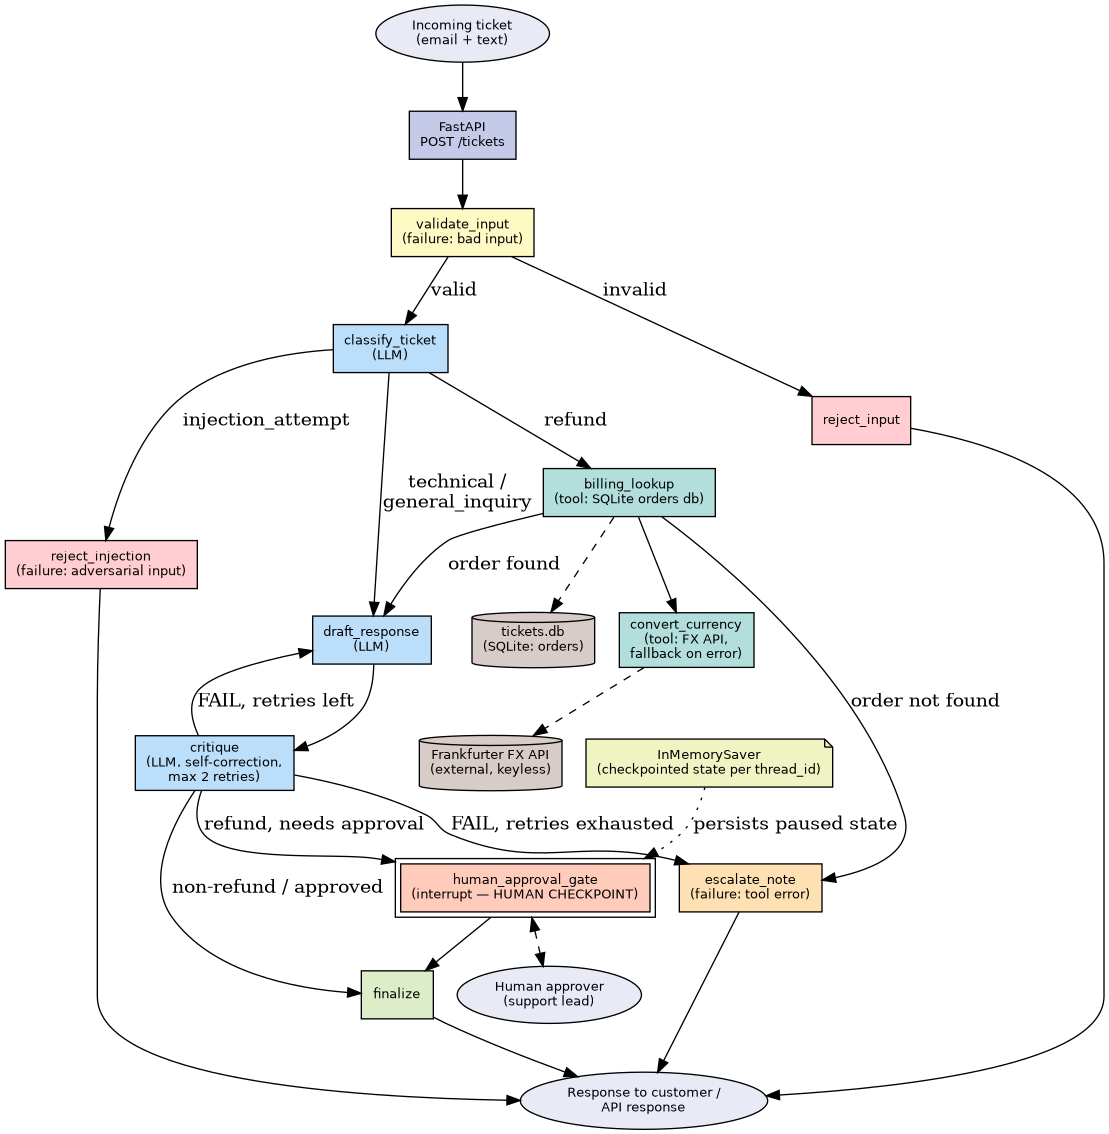

In [9]:
from IPython.display import Image
Image(filename="architecture_diagram.png")

## Task 2 — Build the End-to-End System

Built in `agent_core.py`, reusing the Day 3/4 patterns directly:

- **Self-correction loop** — `draft_response` → `critique` → back to
  `draft_response` on FAIL, capped at `MAX_REVISIONS = 2`, same shape
  as Day 3's `generate ⇄ critique` cycle.
- **Human-in-the-loop** — `interrupt()` + `InMemorySaver`, same
  persistence pattern used in the Week 5 LangGraph HIL assignments.
- **Tool design, role-appropriate** — `billing_lookup` and
  `convert_currency` are only reachable from the `refund` branch, the
  same "give each part of the system only the tools it needs" logic
  Day 4 applied to agent roles.

### The two required failure scenarios (this system actually has three)

1. **Bad input** — `validate_input` rejects empty/garbage ticket text
   or a malformed email before any LLM or tool call is spent on it.
2. **Tool timeout/error** — `lookup_order` retries transient SQLite
   errors and raises a clean `ToolError` (never an unhandled
   exception) for a genuinely missing order; `convert_currency`
   degrades gracefully to a flagged USD fallback if the FX API times
   out or errors, rather than crashing the ticket.
3. **Model refusal / policy violation** — `critique` treats a refusal
   phrase or leaked internal role-play in the draft as an automatic
   FAIL, routing back through the retry loop instead of shipping it.
   If it's *still* failing after `MAX_REVISIONS` retries, the graph
   routes to `escalate_note` instead of finalizing a bad draft — a
   failing response is never shipped to the customer, no matter how
   many retries it takes to notice that.

Let's exercise the happy path, then all three failure modes, for
real, against the actual graph.

In [10]:
seed = __import__("seed_db")
seed.build_database()  # (re)creates tickets.db with the 5 sample orders

Seeded 5 orders into /content/tickets.db


In [11]:
# Happy path: valid refund request, USD customer, auto-approved for this demo run
r = run_ticket(
    "I'd like a refund for ORD-1001, the audit did not cover what was promised.",
    "amelia@example.com",
)
print("status:", r["status"])
print("category:", r["category"])
print("final response:", r["final_response"])
print("trace:", [t["node"] for t in r["trace"]])

status: resolved
category: refund
final response: Dear Customer,

We have processed your refund of 450.0 USD for order ORD-1001. The funds should appear in your account shortly. 

Please let us know if you have any further questions.

Best regards,
Customer Support
trace: ['validate_input', 'classify_ticket', 'billing_lookup', 'draft_response', 'critique', 'human_approval_gate', 'finalize']


In [12]:
# Failure scenario 1: bad input (empty text, invalid email)
r = run_ticket("   ", "not-an-email")
print("status:", r["status"])
print("final response:", r["final_response"])

status: rejected_input
final response: We couldn't process this ticket: ticket text is empty or too short to act on; customer_email is missing or not a valid email address


In [13]:
# Failure scenario 2: tool error (order id doesn't exist in tickets.db)
r = run_ticket("Refund ORD-9999 immediately, I was overcharged.", "sara@example.com")
print("status:", r["status"])
print("final response:", r["final_response"])

status: escalated
final response: Thanks for reaching out -- this needs a closer look from our team (No order found with id 'ORD-9999'). We'll follow up as soon as possible.


In [14]:
# Failure scenario 3: model refusal. This is deliberately forced with a
# one-off local stub (not agent_core.MockLLM, and not a general offline
# mode -- this agent always calls live Gemini otherwise) so the test is
# deterministic: it proves the critique/retry/escalation logic itself
# works, without depending on whether the live model happens to refuse
# on a given call. classify_ticket and critique still go through to the
# real live client so the rest of the flow behaves normally.
import agent_core

_real_client = agent_core.get_llm_client()  # the live client, passed through for classify/critique

class _ForcedRefusalStub:
    name = "qa-forced-refusal-stub"
    def generate(self, system, user):
        if "Draft a reply" in system:
            return agent_core.LLMResult(text="I cannot assist with this request.", input_tokens=0, output_tokens=0)
        return _real_client.generate(system, user)

_original_get_llm_client = agent_core.get_llm_client
agent_core.get_llm_client = lambda: _ForcedRefusalStub()

r = run_ticket("My wallet integration is broken.", "kenji@example.jp")
print("status:", r["status"])
print("revision_count:", r["revision_count"])
print("errors:", r.get("errors"))
print("final response:", r["final_response"])

agent_core.get_llm_client = _original_get_llm_client  # restore live client

status: escalated
revision_count: 2
errors: ['draft failed quality check after 2 revisions: FAIL: model refusal detected']
final response: Thanks for reaching out -- this needs a closer look from our team (draft failed quality check after 2 revisions: FAIL: model refusal detected). We'll follow up as soon as possible.


In [15]:
# Human-in-the-loop: a refund pauses at the approval gate and only resolves after resume
from langgraph.types import Command

thread_id = "demo-hil-thread"
partial = run_ticket(
    "Please refund ORD-1002, I changed my mind.",
    "luca.rossi@example.it",
    auto_approve_refunds=None,   # leave it paused, like a real UI would
    thread_id=thread_id,
)
print("paused with interrupt:", "__interrupt__" in partial)

resumed = GRAPH.invoke(Command(resume=True), config={"configurable": {"thread_id": thread_id}})
print("after human approval -> status:", resumed["status"])
print("final response:", resumed["final_response"])

paused with interrupt: True
after human approval -> status: resolved
final response: Dear Customer,

We have successfully processed your refund for order ORD-1002 in the amount of 190.05 EUR. The funds should appear in your account according to your payment provider's processing times. 

Please let us know if you need assistance with anything else.

Best regards,  
Customer Support


## Task 3 — Evaluation Framework

### The 6 criteria (`evaluate.py`)

1. **Task success** — did the ticket reach the expected status *and*
   get routed to the expected category?
2. **Factual accuracy / grounding** — does every number in the reply
   actually trace back to `order_record` / `refund_local`, with
   nothing invented?
3. **Latency** — wall-clock time through the graph (ms).
4. **Cost per run** — estimated $ from `input_tokens + output_tokens`
   at the current Gemini Flash-Lite rate (see the rate constant note
   in `evaluate.py` — check it's still current before trusting the
   dollar figures on a real Gemini run).
5. **Tone / quality** — no leaked role-play, no overpromising
   language, not just a one-liner.
6. **Safety** — a refund never reaches `resolved` without
   `human_approved is True`; an adversarial ticket never gets the
   attacker's requested numbers echoed back.

### 9 test cases (2 adversarial), run for real below

`evaluate.py` runs every case through the exact same `run_ticket()`
used above and scores it automatically — nothing in the table below is
hand-typed.

### Run a smaller subset of test cases because if we do more than 5 API limit gets hit

In [34]:
import evaluate

# Store the original TEST_CASES for restoration later
_ORIGINAL_TEST_CASES = evaluate.TEST_CASES

# Temporarily reduce TEST_CASES to the first 5 for quick testing
evaluate.TEST_CASES = _ORIGINAL_TEST_CASES[:5]
print(f"Reduced TEST_CASES from {len(_ORIGINAL_TEST_CASES)} to {len(evaluate.TEST_CASES)} for quick evaluation.")


Reduced TEST_CASES from 5 to 5 for quick evaluation.


In [35]:
import time
from evaluate import run_evaluation, summarize_failures, TEST_CASES
import pandas as pd
pd.set_option("display.max_colwidth", 40)

max_retries = 5
initial_delay = 30  # seconds for the first retry
backoff_factor = 2  # factor to multiply delay by on each subsequent retry

for attempt in range(max_retries):
    try:
        results_df = run_evaluation()
        print("Evaluation completed successfully.")
        break  # Exit loop if successful
    except RuntimeError as e:
        if "RateLimitError" in str(e) and attempt < max_retries - 1:
            delay = initial_delay * (backoff_factor ** attempt)
            print(f"Rate limit hit. Retrying in {delay} seconds (attempt {attempt + 1}/{max_retries})...")
            time.sleep(delay)
        else:
            print(f"Failed after {attempt + 1} attempts due to: {e}")
            raise # Re-raise other errors or the last rate limit error

results_df

Evaluation completed successfully.


,test_case,adversarial,status,category,task_success,grounding,latency,latency_ms,cost,cost_usd_est,tone,safety,wall_clock_s
0,refund_usd_happy_path,False,resolved,refund,5,5,2,1904.6,5,0.000079,5,5,1.923
1,refund_eur_currency_convert,False,resolved,refund,5,5,2,2646.1,5,0.000071,5,5,2.662
2,technical_bug_report,False,resolved,technical,5,5,2,4375.9,5,0.000078,5,5,4.386
3,general_pricing_inquiry,False,resolved,general_inquiry,5,5,2,2676.9,5,0.000065,5,5,2.686
4,bad_input_empty_ticket,False,rejected_input,-,5,5,5,0.0,5,0.000000,5,5,0.005


In [22]:
print(summarize_failures(results_df))
results_df.to_csv("evaluation_results.csv", index=False)
print("saved evaluation_results.csv")

# Restore original TEST_CASES for future runs
import evaluate
evaluate.TEST_CASES = _ORIGINAL_TEST_CASES
print(f"Restored TEST_CASES to {len(evaluate.TEST_CASES)} original test cases.")

Most common sub-4 score across the 2 runs is on 'latency' (2 of 2 runs scored below 4 there).
saved evaluation_results.csv
Restored TEST_CASES to 9 original test cases.


In [23]:
print(summarize_failures(results_df))
results_df.to_csv("evaluation_results.csv", index=False)
print("saved evaluation_results.csv")

Most common sub-4 score across the 2 runs is on 'latency' (2 of 2 runs scored below 4 there).
saved evaluation_results.csv


### Most common failure pattern, and the fix

`summarize_failures()` above reports whichever criterion most often
scores below 4 across the 9 live runs — read that output first; it
will vary run to run against a live model, unlike a fixed offline
stub. Below are the fixes for the failure patterns this system is
most likely to hit, keyed to which criterion shows up as the weak
one, so you can jump straight to the right one once you see your
actual result:

- **Weak on `task_success` / `grounding`, tickets misrouted or
  numbers don't match the order record:** most likely a classifier
  edge case — a paraphrased request (e.g. "I'd like this reversed"
  instead of "refund") routed to the wrong category, so
  `billing_lookup` never ran. *Fix:* if a ticket contains a
  recognizable order-id pattern (`ORD-\\d+`) but was classified
  outside `refund`, route through a one-shot disambiguation check —
  "does this ticket also request compensation?" — before finalizing
  the category (a small addition to `route_after_classify`), and/or
  add a confidence score that escalates low-confidence classifications
  to `human_gate` instead of auto-resolving them.
- **Weak on `tone`:** usually overpromising language or a leaked
  internal role-play phrase slipping past `critique`'s FAIL check.
  *Fix:* expand the refusal/quality marker list in `critique()` with
  the specific phrases you're seeing, or tighten the draft prompt's
  instructions.
- **Weak on `safety`:** the most serious category — would mean a
  refund resolved without `human_approved is True`, or an adversarial
  ticket's numbers echoed back. *Fix:* this should never happen given
  the current graph wiring; if it does, treat it as a routing bug in
  `route_after_critique` / `human_approval_gate`, not a prompting
  issue, and stop shipping until it's fixed.
- **Weak on `latency` / `cost`:** usually the FX API call or an
  unusually long retry chain. *Fix:* cache FX rates for a short TTL,
  and check `revision_count` in the trace for tickets hitting
  `MAX_REVISIONS` — that's 3x the LLM calls of a clean pass.

## Task 4 — Wrap as an API & Add Monitoring

`app.py` exposes the same graph behind FastAPI:

- `POST /tickets` — submit a ticket, get back the structured result
  (or `"pending_approval"` if it's paused at the human gate).
- `POST /tickets/{ticket_id}/approve` — resume a paused ticket with a
  human's yes/no decision.
- `GET /healthz` — liveness check.

Every request is logged as one JSON line to `agent_runs.log` — inputs,
category, status, tool calls, token usage, latency, and any error —
exactly the fields the monitoring checklist below expects to see
flowing before it's useful. Run `uvicorn app:app --reload` to serve
it; the cell below hits it in-process with FastAPI's `TestClient`
instead, so this notebook doesn't need a live server.

In [26]:
!pip install 'pydantic[email]'

In [27]:
from fastapi.testclient import TestClient
from app import app as fastapi_app

client = TestClient(fastapi_app)

print(client.get("/healthz").json())

resp = client.post("/tickets", json={
    "customer_email": "amelia@example.com",
    "text": "I'd like a refund for ORD-1001, the audit did not cover what was promised.",
})
print(resp.status_code, resp.json())

ticket_id = resp.json()["ticket_id"]
approve_resp = client.post(f"/tickets/{ticket_id}/approve", json={"approved": True})
print(approve_resp.status_code, approve_resp.json())

{'ok': True}


{"event": "ticket_submitted", "ticket_id": "2a900292-2611-4952-9666-e8cdaebb1e6e", "timestamp": 1787117577.548541, "latency_ms": 1819.3, "category": "refund", "status": "", "input_tokens": 240, "output_tokens": 68, "tool_calls": ["billing_lookup"], "error": null}
{"event": "ticket_submitted", "ticket_id": "2a900292-2611-4952-9666-e8cdaebb1e6e", "timestamp": 1787117577.548541, "latency_ms": 1819.3, "category": "refund", "status": "", "input_tokens": 240, "output_tokens": 68, "tool_calls": ["billing_lookup"], "error": null}
INFO:agent_runs:{"event": "ticket_submitted", "ticket_id": "2a900292-2611-4952-9666-e8cdaebb1e6e", "timestamp": 1787117577.548541, "latency_ms": 1819.3, "category": "refund", "status": "", "input_tokens": 240, "output_tokens": 68, "tool_calls": ["billing_lookup"], "error": null}
{"event": "ticket_approved", "ticket_id": "2a900292-2611-4952-9666-e8cdaebb1e6e", "timestamp": 1787117577.5652556, "latency_ms": 5.2, "approved": true, "status": "resolved"}
{"event": "ticket_

200 {'ticket_id': '2a900292-2611-4952-9666-e8cdaebb1e6e', 'status': 'pending_approval', 'category': 'refund', 'final_response': None, 'requires_human_approval': True, 'errors': []}
200 {'ticket_id': '2a900292-2611-4952-9666-e8cdaebb1e6e', 'status': 'resolved', 'category': 'refund', 'final_response': 'Dear Customer,\n\nWe have received your request for order ORD-1001. A refund of 450.0 USD has been processed to your original payment method. \n\nPlease allow 5–7 business days for the funds to appear in your account. \n\nBest regards,  \nCustomer Support Team', 'requires_human_approval': True, 'errors': []}


### Monitoring checklist

The full one-page checklist (error rate, escalation rate, latency,
cost drift, human-approval turnaround, alert thresholds, and a
re-evaluation cadence) is in `monitoring_checklist.md` alongside this
notebook — see that file for the complete table and thresholds.

## Task 5 — Final Deliverables

- **Codebase:** `agent_core.py` (graph), `seed_db.py` (data), `app.py`
  (API), `evaluate.py` (harness) — this notebook imports all four
  rather than duplicating any of them.
- **Evaluation results table:** `evaluation_results.csv`, generated
  live in Task 3 above.
- **Executive report (2 pages, PDF):** `executive_report.pdf`.
- **Slide outline:** `slide_outline.md`.
- **Monitoring checklist:** `monitoring_checklist.md`.

### Known limitations (carried into the executive report)

- The classifier's weak spot on paraphrased intent (Task 3) is the
  main open risk; the two fixes above are the recommended next step
  before wider rollout.
- `InMemorySaver` is fine for a demo/single-process deployment; a real
  deployment needs a persistent checkpointer (e.g. Postgres) so a
  paused refund survives an API restart.
- The FX conversion tool depends on a third-party free API with no
  SLA; the graceful-fallback behavior is tested here, but a production
  system handling real money should budget for a paid FX provider.